In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("D:\FYP\OperatorSkillPrediction\dataset\dataset.csv")

print(df.shape)

df.head()

(631, 8)


<>:1: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
<>:1: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
C:\Users\Asus\AppData\Local\Temp\ipykernel_10136\1145417128.py:1: SyntaxWarning: "\F" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\F"? A raw string is also an option.
  df = pd.read_csv("D:\FYP\OperatorSkillPrediction\dataset\dataset.csv")


,Style,Line Number,Operation,SMV,Actual Output,Target Output,Efficiency,Skill_Label
0,HOS26HS004,6,SHOULDER SEAM EDGE TACK,0.24,602,1242,26.75,B
1,HOS26HS004,6,BTM HEM,1.00,210,297,38.88,C
2,HOS26HS004,6,SIDE LABEL TACK,0.30,482,880,26.77,B
3,HOS26HS004,6,BTM SIDE SEAM,0.94,240,315,41.77,A
4,HOS26HS004,6,NECK EDGE TACK,0.44,523,675,42.61,B


In [3]:
print(df.columns)

Index(['Style', ' Line Number ', ' Operation ', ' SMV ', ' Actual Output ',
       ' Target Output ', ' Efficiency ', ' Skill_Label '],
      dtype='str')


In [4]:
df.columns = df.columns.str.strip()

In [5]:
print(df.columns)

Index(['Style', 'Line Number', 'Operation', 'SMV', 'Actual Output',
       'Target Output', 'Efficiency', 'Skill_Label'],
      dtype='str')


In [6]:
print(df["Skill_Label"].value_counts())

print(df["Skill_Label"].value_counts(normalize=True)*100)

Skill_Label
B     252
A     212
A+    122
C      45
Name: count, dtype: int64
Skill_Label
B     39.936609
A     33.597464
A+    19.334390
C      7.131537
Name: proportion, dtype: float64


In [7]:
from sklearn.preprocessing import LabelEncoder

style_encoder = LabelEncoder()
operation_encoder = LabelEncoder()
skill_encoder = LabelEncoder()

df["Style"] = style_encoder.fit_transform(df["Style"])
df["Operation"] = operation_encoder.fit_transform(df["Operation"])
df["Skill_Label"] = skill_encoder.fit_transform(df["Skill_Label"])

In [8]:
df.head()

,Style,Line Number,Operation,SMV,Actual Output,Target Output,Efficiency,Skill_Label
0,1,6,38,0.24,602,1242,26.75,2
1,1,6,9,1.00,210,297,38.88,3
2,1,6,41,0.30,482,880,26.77,2
3,1,6,10,0.94,240,315,41.77,0
4,1,6,24,0.44,523,675,42.61,2


In [9]:
X = df.drop("Skill_Label", axis=1)
y = df["Skill_Label"]

print(X.shape)
print(y.shape)

(631, 7)
(631,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(504, 7)
(127, 7)
(504,)
(127,)


In [11]:
print(y_train.value_counts())

Skill_Label
2    201
0    169
1     98
3     36
Name: count, dtype: int64


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(pd.Series(y_train_smote).value_counts())

Skill_Label
0    201
1    201
2    201
3    201
Name: count, dtype: int64


In [13]:
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
print(skill_encoder.classes_)

['A' 'A+' 'B' 'C']


In [15]:
print("Before SMOTE")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
Skill_Label
2    201
0    169
1     98
3     36
Name: count, dtype: int64

After SMOTE
Skill_Label
0    201
1    201
2    201
3    201
Name: count, dtype: int64


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[0 1 2 2 2 0 1 3 2 0]


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.968503937007874


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        43
           1       1.00      0.96      0.98        24
           2       0.96      0.98      0.97        51
           3       1.00      0.78      0.88         9

    accuracy                           0.97       127
   macro avg       0.98      0.93      0.95       127
weighted avg       0.97      0.97      0.97       127



In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[43  0  0  0]
 [ 1 23  0  0]
 [ 1  0 50  0]
 [ 0  0  2  7]]


In [21]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Precision: 0.9695066962783497
Recall: 0.968503937007874
F1 Score: 0.9677295439500083


In [22]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

         Feature  Importance
2      Operation    0.252569
5  Target Output    0.171708
3            SMV    0.167483
6     Efficiency    0.158730
4  Actual Output    0.134722
1    Line Number    0.074064
0          Style    0.040725


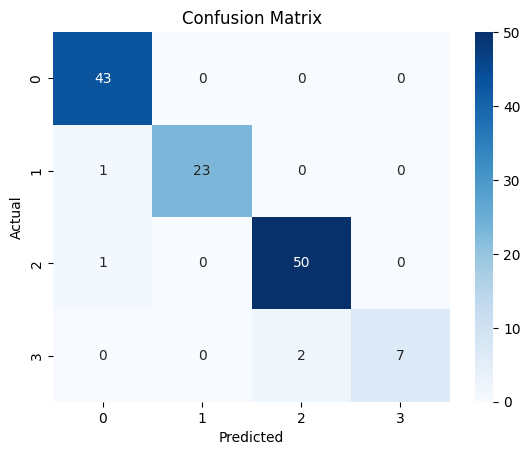

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

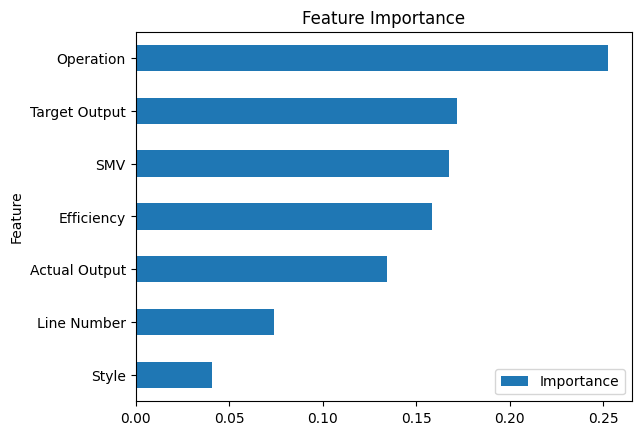

In [24]:
feature_importance.sort_values(
    by='Importance',
    ascending=True
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title("Feature Importance")
plt.show()

In [25]:
import joblib

joblib.dump(rf_model, "skill_prediction_model.pkl")

['skill_prediction_model.pkl']

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_smote, y_train_smote)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, dt_pred))

Accuracy: 0.9606299212598425
F1 Score: 0.9589257509214645

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.96      0.98        24
           2       0.94      0.98      0.96        51
           3       0.86      0.67      0.75         9

    accuracy                           0.96       127
   macro avg       0.94      0.90      0.92       127
weighted avg       0.96      0.96      0.96       127



In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_smote, y_train_smote)

knn_pred = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_pred))
print("F1 Score:", f1_score(y_test, knn_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, knn_pred))

Accuracy: 0.6929133858267716
F1 Score: 0.6937786622825993

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.74      0.70        43
           1       0.63      0.71      0.67        24
           2       0.80      0.63      0.70        51
           3       0.58      0.78      0.67         9

    accuracy                           0.69       127
   macro avg       0.67      0.71      0.68       127
weighted avg       0.71      0.69      0.69       127



In [28]:
results = {
    "Model": ["Random Forest", "Decision Tree", "KNN"],
    "Accuracy": [96.85, 96.06, 69.29],
    "F1 Score": [96.77, 95.89, 69.38]
}

import pandas as pd

comparison_df = pd.DataFrame(results)

print(comparison_df)

           Model  Accuracy  F1 Score
0  Random Forest     96.85     96.77
1  Decision Tree     96.06     95.89
2            KNN     69.29     69.38


In [29]:
import joblib

rf_model = joblib.load("skill_prediction_model.pkl")

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_cv = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf_cv,
    X,
    y,
    cv=skf,
    scoring='accuracy'
)

print("Fold Accuracies:")
print(scores)

print("\nMean Accuracy:")
print(scores.mean())

print("\nStandard Deviation:")
print(scores.std())

Fold Accuracies:
[0.91338583 0.95238095 0.88095238 0.92063492 0.95238095]

Mean Accuracy:
0.9239470066241718

Standard Deviation:
0.026788149666350323


In [31]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

print("SHAP ready")

SHAP ready


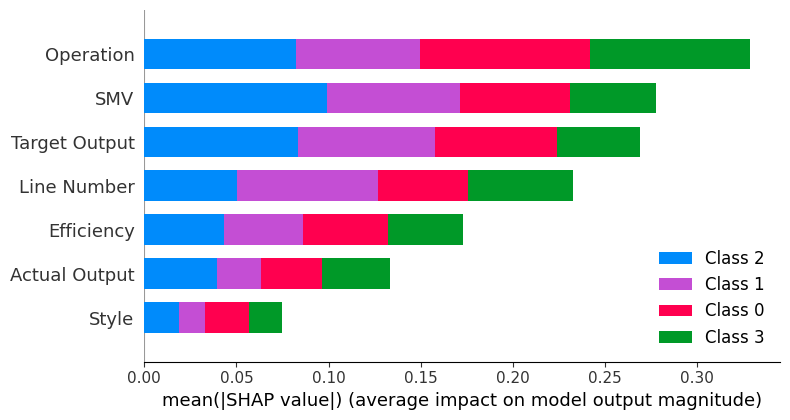

In [32]:
import shap
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

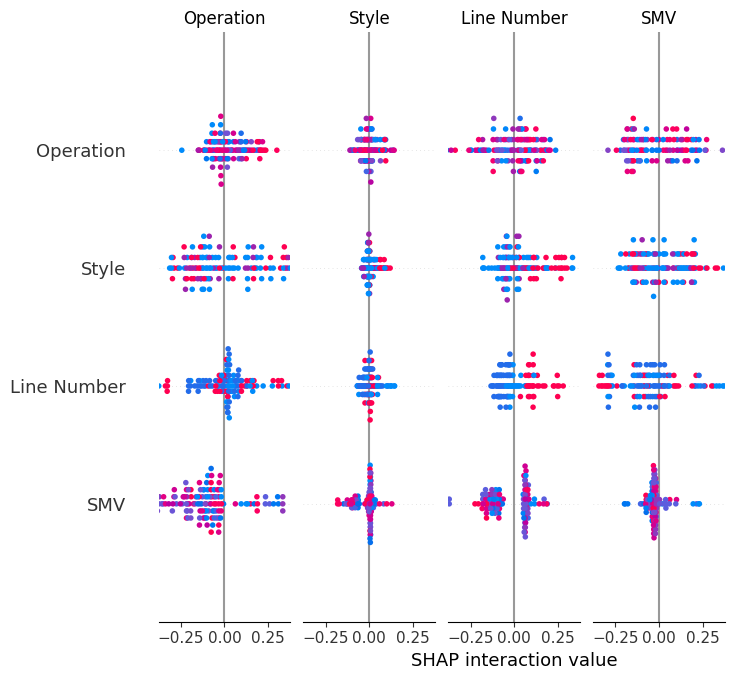

In [33]:
shap.summary_plot(
    shap_values,
    X_test
)

In [34]:
print(shap_values.shape)

(127, 7, 4)


In [35]:
# import shap

# explainer = shap.TreeExplainer(xgb)

# shap_values = explainer.shap_values(X_test_encoded)

# shap.plots.waterfall(
#     shap.Explanation(
#         values=shap_values[0],
#         base_values=explainer.expected_value,
#         data=X_test_encoded[0].toarray()[0]if hasattr(X_test_encoded[0], "toarray")else X_test_encoded[0],
#         feature_names=preprocessor.get_feature_names_out()
#     )
# )

In [36]:
import joblib

joblib.dump(rf_model, "skill_prediction_model.pkl")

print("Model saved successfully")

Model saved successfully


In [37]:
joblib.dump(style_encoder, "style_encoder.pkl")
joblib.dump(operation_encoder, "operation_encoder.pkl")

print("Encoders saved successfully")

Encoders saved successfully


In [38]:
import os

print(os.listdir())

['operation_encoder.pkl', 'skill_prediction.ipynb', 'skill_prediction_model.pkl', 'style_encoder.pkl']


In [39]:
print(style_encoder.classes_)

['HOS26DR042' 'HOS26HS004' 'TRENDY0207']


In [40]:
print(operation_encoder.classes_)

['1st SHELL BTM SIDE SEAM' 'ARMHOLE RUN' 'BACK CENTER SEAM JOIN SHELL'
 'BACK NECK PIPING' 'BACK NECK PIPING CLOSE' 'BOTTOM HEM OL'
 'BTM FRILL ATT BACK' 'BTM FRILL ATT FRONT' 'BTM FRILL ATTACH TO MID PART'
 'BTM HEM' 'BTM SIDE SEAM' 'FRONT CENTER JOINT' 'FRONT NECK CLOSE'
 'FRONT NECK OUTLINE' 'FRONT NECK TAP ATT' 'FRONT TOP WAIST GATHERING'
 'FRONT WAIST ATT' 'FRONT WAIST OL' 'HANGDER LOOP TACK' 'LABEL TACK'
 'LINING TOP SIDE SEAM' 'NARROW THE BTM' 'NECK ATTACH' 'NECK EDGE PRE OL'
 'NECK EDGE TACK' 'NECK FOLD LOOS TACK' 'NECK LABEL TACK' 'NECK OUTLINE'
 'NECK SMOKING' 'NECK TAPE JOIN' 'NECK TAPE PRE OL' 'OL THREAD TACK'
 'PERE WAY ATTACH TO FRONT' 'SHELL SHOULDER ATTACH' 'SHELL TOP SIDE SEAM'
 'SHOULDER PAD OVER LOCK' 'SHOULDER PAD TACK BOTH SIDE'
 'SHOULDER PAD TACK TO HANGER' 'SHOULDER SEAM EDGE TACK' 'SHOULDER TACK'
 'SHOULDER TAPE ATTACH' 'SIDE LABEL TACK' 'SIDE SEAM' 'SLEEVE ARM RUN'
 'SLEEVE ATT' 'SLEEVE ATT BACK *2' 'SLEEVE ATTACH' 'SLEEVE CENTER TACK'
 'SLEEVE ELASTIC ATT' 'S

In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_xgb = xgb_model.predict(X_test)

In [42]:
# import shap

# explainer = shap.TreeExplainer(xgb_model)

# shap_values = explainer.shap_values(X_test_encoded)

# shap.plots.waterfall(
#     shap.Explanation(
#         values=shap_values[0],
#         base_values=explainer.expected_value,
#         data=X_test_encoded[0].toarray()[0]if hasattr(X_test_encoded[0], "toarray")else X_test_encoded[0],
#         feature_names=preprocessor.get_feature_names_out()
#     )
# )

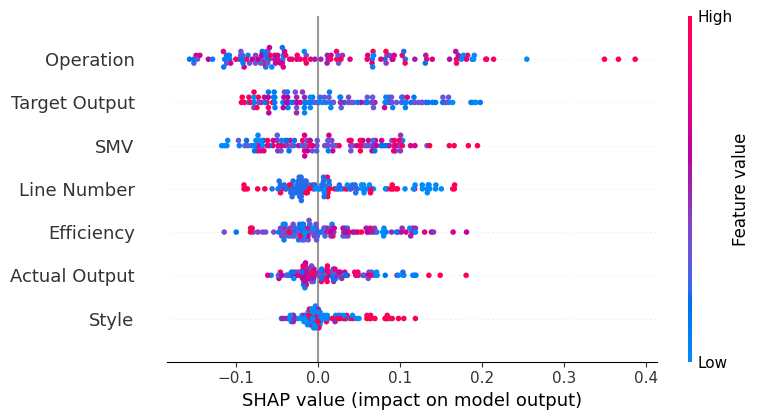

In [43]:
shap.summary_plot(
    shap_values[:, :, 0],
    X_test,
    feature_names=X_test.columns
)

In [44]:
import numpy as np

mean_shap = np.abs(shap_values).mean(axis=(0,2))

for feature, value in zip(X_test.columns, mean_shap):
    print(feature, value)

Style 0.018749192952748496
Line Number 0.05825298742889491
Operation 0.0821800321813524
SMV 0.06945924180468996
Actual Output 0.033372423265816645
Target Output 0.06730263430093006
Efficiency 0.04331535097370432


In [45]:
sample_index = 0

print("Actual:", y_test.iloc[sample_index])
print("Predicted:", y_pred[sample_index])

Actual: 0
Predicted: 0


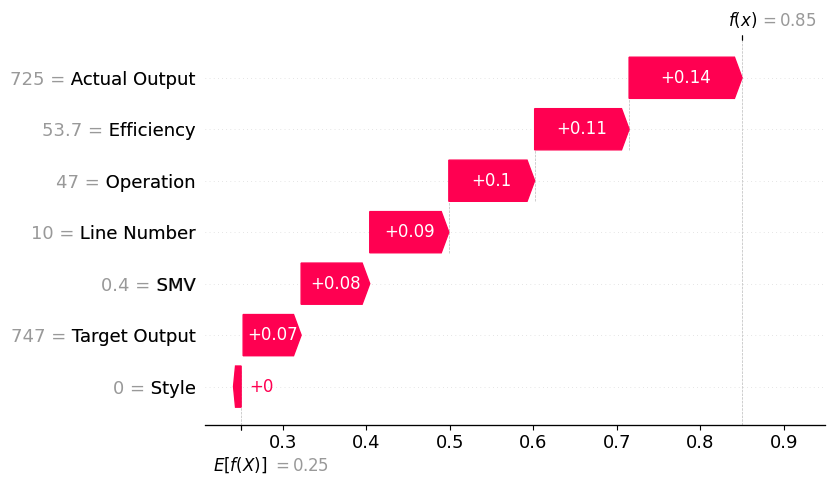

In [46]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index,:,y_pred[sample_index]],
        base_values=explainer.expected_value[y_pred[sample_index]],
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

In [47]:
print(X.columns.tolist())

['Style', 'Line Number', 'Operation', 'SMV', 'Actual Output', 'Target Output', 'Efficiency']


In [48]:
import shap
import joblib

model = joblib.load("../backend/models/skill_prediction_model.pkl")
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test.iloc[[0]])

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(1, 7, 4)


In [49]:
train_data = X_train.copy()
train_data["Skill Level"] = y_train

test_data = X_test.copy()
test_data["Skill Level"] = y_test

train_data.to_csv("../dataset/train_dataset.csv", index=False)
test_data.to_csv("../dataset/test_dataset.csv", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.
